# Iteration 2 — Expanded Dataset Training

Trains **YOLO26n**, **RT-DETR-l**, and **RF-DETR Nano** for **100 epochs** each
on the expanded dataset (original + real-world wallet + custom sunglasses/wallet images).

Run `clean.ipynb` merge cells before running this notebook.

## Data Preprocessing

This section audits dataset quality, removes near-duplicates, checks class balance, verifies train/val/test splits, applies letterbox resizing to 640x640, and augments training images — all before model training begins.

In [17]:
%pip install imagehash albumentations -q

from pathlib import Path
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ── Configuration ─────────────────────────────────────────────────────────────
DATASET_PATH = Path('../data')
CLASSES = ['Sunglasses', 'Keys', 'Wallet']
SPLITS = ['train', 'valid', 'test']
IMG_SIZE = 640

Note: you may need to restart the kernel to use updated packages.


### Step 1: Dataset Quality Audit

Count images per split and class, detect near-duplicates via perceptual hashing, identify corrupted images, and flag missing or empty annotation files.

In [18]:
import imagehash

print('=' * 60)
print('STEP 1: Dataset Quality Audit')
print('=' * 60)

# 1a. Image counts per split
print('\n--- Images per split ---')
for split in SPLITS:
    imgs = [f for f in (DATASET_PATH / split / 'images').glob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f'  {split}: {len(imgs)} images')

# 1b. Instance counts per class per split
print('\n--- Instances per class per split ---')
for split in SPLITS:
    counts = Counter()
    for lbl in (DATASET_PATH / split / 'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(line.split()[0])
                if cls_id < len(CLASSES):
                    counts[CLASSES[cls_id]] += 1
    print(f'  {split}: {dict(counts)}')

# 1c. Near-duplicate detection via perceptual hashing
print('\n--- Near-duplicate detection ---')
hash_map = {}
duplicates = []
for split in SPLITS:
    for img_path in sorted((DATASET_PATH / split / 'images').glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        try:
            h = str(imagehash.phash(Image.open(img_path)))
            if h in hash_map:
                duplicates.append((hash_map[h], (split, img_path.name)))
            else:
                hash_map[h] = (split, img_path.name)
        except Exception:
            pass  # handled in corrupted check below

if duplicates:
    print(f'  Found {len(duplicates)} near-duplicate pair(s):')
    for orig, dup in duplicates[:10]:
        print(f'    {orig[0]}/{orig[1]}  <->  {dup[0]}/{dup[1]}')
    if len(duplicates) > 10:
        print(f'    ... and {len(duplicates) - 10} more')
else:
    print('  No near-duplicates detected.')

# 1d. Corrupted / unreadable images
print('\n--- Corrupted images ---')
corrupted = []
for split in SPLITS:
    for img_path in sorted((DATASET_PATH / split / 'images').glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        try:
            with Image.open(img_path) as im:
                im.verify()
        except Exception as e:
            corrupted.append(f'{split}/{img_path.name}: {e}')

if corrupted:
    print(f'  Found {len(corrupted)} corrupted image(s):')
    for c in corrupted:
        print(f'    {c}')
else:
    print('  All images readable.')

# 1e. Missing or empty annotation files
print('\n--- Missing / empty annotations ---')
missing, empty = [], []
for split in SPLITS:
    imgs_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'
    for img_path in sorted(imgs_dir.glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        lbl = labels_dir / (img_path.stem + '.txt')
        if not lbl.exists():
            missing.append(f'{split}/{img_path.name}')
        elif not lbl.read_text().strip():
            empty.append(f'{split}/{img_path.name}')

print(f'  Missing label files: {len(missing)}')
for m in missing[:5]:
    print(f'    {m}')
if len(missing) > 5:
    print(f'    ... and {len(missing) - 5} more')
print(f'  Empty label files (background / negative samples): {len(empty)}')
for e in empty[:5]:
    print(f'    {e}')
if len(empty) > 5:
    print(f'    ... and {len(empty) - 5} more')

print('\nStep 1 complete.')

STEP 1: Dataset Quality Audit

--- Images per split ---
  train: 4913 images
  valid: 289 images
  test: 232 images

--- Instances per class per split ---
  train: {'Keys': 2196, 'Sunglasses': 1507, 'Wallet': 2102}
  valid: {'Wallet': 159, 'Keys': 144, 'Sunglasses': 60}
  test: {'Wallet': 118, 'Keys': 130, 'Sunglasses': 40}

--- Near-duplicate detection ---
  Found 261 near-duplicate pair(s):
    train/00106210101918____1__516x640_jpg.rf.771c16aa57f7c1b9ffd62294fefb8a99.jpg  <->  train/00106210101918____1__516x640_jpg.rf.771c16aa57f7c1b9ffd62294fefb8a99_aug1.jpg
    train/01_124623c5-669a-473b-8647-756219f53661_1024x1024_jpg.rf.5c9e9cea0f169af6f9f600d3b3548a13.jpg  <->  train/01_124623c5-669a-473b-8647-756219f53661_1024x1024_jpg.rf.5c9e9cea0f169af6f9f600d3b3548a13_aug1.jpg
    train/01_jpg.rf.2afd52fd7b5cf9dc5ea816b0eca9d52c.jpg  <->  train/01_jpg.rf.2afd52fd7b5cf9dc5ea816b0eca9d52c_aug1.jpg
    train/0802_TopNav_Bags_Wallets_Mobile-2x_jpg.rf.b7246b1270fb9563d33e6260c6d34e8d.jpg  <->  

### Step 2: Near-Duplicate Removal

Remove one image from each near-duplicate pair detected in Step 1. This prevents the model from memorising repeated examples and ensures cleaner evaluation metrics. The **second** occurrence (the duplicate) is deleted along with its label file.

In [19]:
print('=' * 60)
print('STEP 2: Near-Duplicate Removal')
print('=' * 60)

removed = 0
kept_empty_removed = 0

for orig, dup in duplicates:
    dup_split, dup_name = dup
    img_path = DATASET_PATH / dup_split / 'images' / dup_name
    lbl_path = DATASET_PATH / dup_split / 'labels' / (Path(dup_name).stem + '.txt')

    if img_path.exists():
        img_path.unlink()
        removed += 1
    if lbl_path.exists():
        # Check if the label was empty (background sample)
        if not lbl_path.read_text().strip():
            kept_empty_removed += 1
        lbl_path.unlink()

print(f'  Removed {removed} duplicate images (and their labels).')
print(f'  Of those, {kept_empty_removed} had empty labels (background samples).')

# Recount after removal
print('\n--- Post-dedup image counts ---')
for split in SPLITS:
    imgs = [f for f in (DATASET_PATH / split / 'images').glob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f'  {split}: {len(imgs)} images')

print('\n--- Post-dedup instances per class per split ---')
for split in SPLITS:
    counts = Counter()
    for lbl in (DATASET_PATH / split / 'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(line.split()[0])
                if cls_id < len(CLASSES):
                    counts[CLASSES[cls_id]] += 1
    print(f'  {split}: {dict(counts)}')

print('\nStep 2 complete.')

STEP 2: Near-Duplicate Removal
  Removed 261 duplicate images (and their labels).
  Of those, 0 had empty labels (background samples).

--- Post-dedup image counts ---
  train: 4656 images
  valid: 287 images
  test: 230 images

--- Post-dedup instances per class per split ---
  train: {'Keys': 2049, 'Sunglasses': 1431, 'Wallet': 2009}
  valid: {'Wallet': 159, 'Keys': 140, 'Sunglasses': 60}
  test: {'Wallet': 118, 'Keys': 126, 'Sunglasses': 40}

Step 2 complete.


### Step 3: Class Balance Check

Count bounding box instances per class across the full dataset. Flag any class whose count falls below 70% of the most-frequent class.

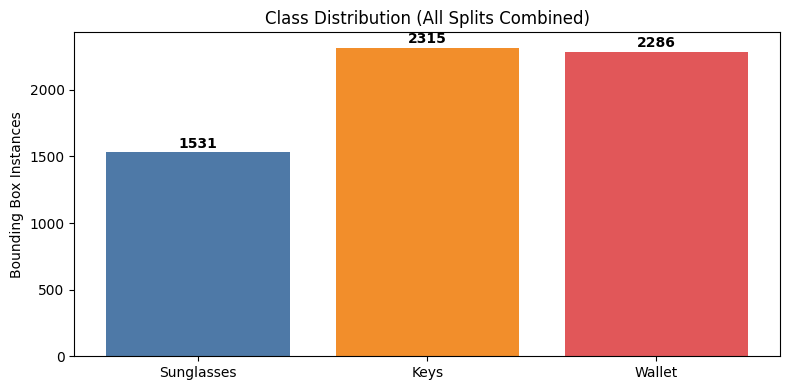

Class balance check (threshold: 70% of most frequent):
  Sunglasses: 1531 — LOW (< 1620)
  Keys: 2315 — OK
  Wallet: 2286 — OK

Step 2 complete.


In [20]:
# Count bounding box instances per class across all splits
total_counts = Counter()
for split in SPLITS:
    for lbl in (DATASET_PATH / split / 'labels').glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(line.split()[0])
                if cls_id < len(CLASSES):
                    total_counts[CLASSES[cls_id]] += 1

# Plot class distribution
counts_list = [total_counts.get(cls, 0) for cls in CLASSES]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASSES, counts_list, color=['#4e79a7', '#f28e2b', '#e15759'])
ax.set_ylabel('Bounding Box Instances')
ax.set_title('Class Distribution (All Splits Combined)')
for bar, count in zip(bars, counts_list):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Flag under-represented classes (< 70% of the most frequent)
max_count = max(counts_list)
threshold = 0.7 * max_count
print('Class balance check (threshold: 70% of most frequent):')
for cls, count in zip(CLASSES, counts_list):
    status = 'OK' if count >= threshold else f'LOW (< {threshold:.0f})'
    print(f'  {cls}: {count} — {status}')

print('\nStep 2 complete.')

### Step 4: Train / Val / Test Split Verification

Confirm the existing Roboflow splits are close to the standard 70/20/10 or 80/10/10 ratio. Warn if any split deviates by more than 5 percentage points.

In [21]:
# Count images per split
split_counts = {}
for split in SPLITS:
    imgs = [f for f in (DATASET_PATH / split / 'images').glob('*')
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    split_counts[split] = len(imgs)

total = sum(split_counts.values())
ratios = {s: c / total * 100 for s, c in split_counts.items()}

print('Split ratios:')
for split, count in split_counts.items():
    print(f'  {split:6s}: {count:5d} images ({ratios[split]:5.1f}%)')
print(f'  {"total":6s}: {total:5d} images')

# Check against standard targets
targets = [
    {'name': '70/10/20', 'train': 70, 'valid': 10, 'test': 20},
    {'name': '80/10/10', 'train': 80, 'valid': 10, 'test': 10},
]

print('\nDeviation from standard splits:')
for t in targets:
    deviations = {s: abs(ratios[s] - t[s]) for s in SPLITS}
    max_dev = max(deviations.values())
    status = 'OK' if max_dev < 5 else 'WARNING — significant deviation'
    print(f'  vs {t["name"]}: max deviation = {max_dev:.1f}% — {status}')

print('\nStep 3 complete.')

Split ratios:
  train :  4656 images ( 90.0%)
  valid :   287 images (  5.5%)
  test  :   230 images (  4.4%)
  total :  5173 images

Deviation from standard splits:
  vs 70/10/20: max deviation = 20.0% — WARNING — significant deviation
  vs 80/10/10: max deviation = 10.0% — WARNING — significant deviation

Step 3 complete.


### Step 5: Online Augmentation Transforms

Define `ONLINE_TRANSFORMS` once here, then pass it to every `model.train(...)` call (YOLO26 and RT-DETR) via the `augmentations=` kwarg. Applied **live every epoch** by the dataloader workers — no disk bloat, fresh random state per call, complementary to Ultralytics' built-in transforms (flip/rotate/scale/mosaic/HSV/copy-paste).

Three transforms, chosen for the FindMe use case:
- `RandomBrightnessContrast` — real-world camera exposure variation.
- `MotionBlur` — phone held while walking / subject motion.
- `CoarseDropout` with `fill_value=114` — simulates partial occlusion using the letterbox-grey colour so the 'holes' look like padding, keeping the learned feature distribution consistent.

In [ ]:
import albumentations as A

# Online augmentation -- applied per-batch by the Ultralytics dataloader.
# Same three transforms passed to YOLO26n, YOLO26s, and RT-DETR training cells.
ONLINE_TRANSFORMS = [
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.MotionBlur(blur_limit=7, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=40, max_width=40, fill_value=114, p=0.3),
]


### Step 6: Final Dataset Summary

Summary of the dataset after all preprocessing steps: image counts, per-class instance counts, and a dimension spot-check to verify letterboxing.

In [ ]:
print('=' * 60)
print('FINAL DATASET SUMMARY')
print('=' * 60)

for split in SPLITS:
    imgs_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'

    img_files = [f for f in imgs_dir.glob('*')
                 if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]

    # Count class instances
    class_counts = Counter()
    for lbl in labels_dir.glob('*.txt'):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                cls_id = int(float(line.split()[0]))
                if cls_id < len(CLASSES):
                    class_counts[CLASSES[cls_id]] += 1

    # Spot-check image dimensions (first 50)
    non_target = 0
    for f in img_files[:50]:
        with Image.open(f) as im:
            if im.size != (IMG_SIZE, IMG_SIZE):
                non_target += 1

    print(f'\n{split.upper()} ({len(img_files)} images):')
    if split == 'train':
        try:
            print(f'  Before augmentation: {pre_aug_train_count}')
            print(f'  After augmentation:  {len(img_files)}')
        except NameError:
            print(f'  Total: {len(img_files)}')
    for cls in CLASSES:
        print(f'  {cls}: {class_counts.get(cls, 0)} instances')
    if non_target == 0:
        print(f'  Dimensions: all {IMG_SIZE}x{IMG_SIZE} (spot-checked)')
    else:
        print(f'  WARNING: {non_target}/50 images not {IMG_SIZE}x{IMG_SIZE}')

print('\n' + '=' * 60)
print('Preprocessing complete. Ready for training.')
print('=' * 60)

FINAL DATASET SUMMARY

TRAIN (5621 images):
  Before augmentation: 4656
  After augmentation:  5621
  Sunglasses: 1665 instances
  Keys: 2562 instances
  Wallet: 2499 instances

VALID (287 images):
  Sunglasses: 60 instances
  Keys: 140 instances
  Wallet: 159 instances

TEST (230 images):
  Sunglasses: 40 instances
  Keys: 126 instances
  Wallet: 118 instances

Preprocessing complete. Ready for training.


: 

## YOLO26n Training (100 epochs)

YOLO26n is the primary candidate for on-device Android deployment: small model size, NNAPI-compatible, and the fastest inference in Iteration 1.

## YOLO26n Training

Primary deployment model for Android. Trains for up to 100 epochs with early stopping.

In [1]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data='../data/data.yaml',
    epochs=150,
    imgsz=640,
    batch=64,
    name='yolo26n_iter2',
    patience=30,
    device=0,
    workers=8,              # bumped up — 4090 build can feed data faster
    optimizer='auto',       # let it pick MuSGD for this run length
    # lr0 and lrf removed — let auto handle per the N recipe (lr0=0.0054, lrf=0.0495)
    weight_decay=0.00064,   # matches N pretraining recipe exactly
    warmup_epochs=0.98,     # matches N pretraining recipe exactly
    cos_lr=True,
    mosaic=0.9,
    mixup=0.0,              # off for medium dataset baseline
    copy_paste=0.1,
    scale=0.6,
    fliplr=0.5,
    degrees=5.0,
    hsv_s=0.5,
    hsv_v=0.4,
    close_mosaic=10,
    augmentations=ONLINE_TRANSFORMS,
)

# Quick test-set evaluation
metrics = YOLO('runs/detect/yolo26n_iter2/weights/best.pt').val(
    data='../data/data.yaml', split='test')
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Sunglasses', 'Keys', 'Wallet']):
    print(f'  {name}: {metrics.box.maps[i]:.4f}')

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../data/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.9, multi_scale=0.0, name=yolo26n_iter22

/home/bradtab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 367.1±426.2 MB/s, size: 288.3 KB)
val: Scanning /home/bradtab/git/FYP/ml-training/data/valid/labels.cache... 287 images, 14 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 17.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 22, len(boxes) = 359. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: MuSGD(lr=0.01, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.00064), 126 bias(decay=0.0)
Plotting labels to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/yolo26n_iter22/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/bradtab/git/FYP/ml-tr

## YOLO26n ONNX Export

Exports to ONNX and copies directly into the Android app assets folder.

In [2]:
import shutil
from pathlib import Path
from ultralytics import YOLO

WEIGHTS = 'runs/detect/yolo26n_iter2/weights/best.pt'
ASSETS  = Path('../../mobile-app/app/src/main/assets')

model       = YOLO(WEIGHTS)
export_path = model.export(format='onnx', imgsz=640, opset=17, simplify=True, dynamic=False)

dst = ASSETS / 'yolo26n.onnx'
shutil.copy2(export_path, dst)
print(f'Copied to {dst}  ({dst.stat().st_size / 1e6:.2f} MB)')


Ultralytics 8.4.14 🚀 Python-3.10.19 torch-2.8.0+cu128 CPU (Intel Core i9-14900K)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/yolo26n_iter2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (14.8 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.86...


/home/bradtab/.local/lib/python3.10/site-packages/torch/onnx/symbolic_opset9.py:5350: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(
2026-04-03 11:57:09.398914804 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 1.0s, saved as 'runs/detect/yolo26n_iter2/weights/best.onnx' (9.4 MB)

Export complete (1.2s)
Results saved to /home/bradtab/git/FYP/ml-training/notebooks/runs/detect/yolo26n_iter2/weights
Predict:         yolo predict task=detect model=runs/detect/yolo26n_iter2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/yolo26n_iter2/weights/best.onnx imgsz=640 data=../data/data.yaml  
Visualize:       https://netron.app
Copied to ../../mobile-app/app/src/main/assets/yolo26n.onnx  (9.81 MB)


## YOLO26s Training

S variant — extra capacity over the N model, used to disambiguate the `sunglasses` / `glasses` class pair (the hardest pair in the dataset). Same data, same augmentation, same epoch count — only the model weights and S pretraining recipe (`batch`, `weight_decay`, `warmup_epochs`) differ. Direct N-vs-S comparison is fair.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

results = model.train(
    data='../data/data.yaml',
    epochs=150,
    imgsz=640,
    batch=32,               # S is ~3x larger than N -- halved to fit VRAM
    name='yolo26s_iter1',
    patience=30,
    device=0,
    workers=8,
    optimizer='auto',       # let it pick MuSGD for this run length
    weight_decay=0.0005,    # matches S pretraining recipe
    warmup_epochs=3.0,      # matches S pretraining recipe
    cos_lr=True,
    mosaic=0.9,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.6,
    fliplr=0.5,
    degrees=5.0,
    hsv_s=0.5,
    hsv_v=0.4,
    close_mosaic=10,
    augmentations=ONLINE_TRANSFORMS,
)

# Quick test-set evaluation
metrics = YOLO('runs/detect/yolo26s_iter1/weights/best.pt').val(
    data='../data/data.yaml', split='test')
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Sunglasses', 'Keys', 'Wallet']):
    print(f'  {name}: {metrics.box.maps[i]:.4f}')


## YOLO26s ONNX Export

Exports to ONNX and copies directly into the Android app assets folder. (TFLite export with NMS=true is the deployment path used previously; ONNX kept here for parity with the YOLO26n cell so all three architectures land in `assets/` as ONNX.)

In [ ]:
import shutil
from pathlib import Path
from ultralytics import YOLO

WEIGHTS = 'runs/detect/yolo26s_iter1/weights/best.pt'
ASSETS  = Path('../../mobile-app/app/src/main/assets')

model       = YOLO(WEIGHTS)
export_path = model.export(format='onnx', imgsz=640, opset=17, simplify=True, dynamic=False)

dst = ASSETS / 'yolo26s.onnx'
shutil.copy2(export_path, dst)
print(f'Copied to {dst}  ({dst.stat().st_size / 1e6:.2f} MB)')


## RT-DETR-l Training

Transformer-based baseline for accuracy comparison. Not deployed to Android.

In [1]:
# Clean up any incomplete rtdetr_l_iter2 run before training
# Run this cell whenever you need to restart the RT-DETR training from scratch
import shutil, pathlib

run_dir = pathlib.Path("runs/detect/rtdetr_l_iter2")
if run_dir.exists():
    shutil.rmtree(run_dir)
    print(f"Deleted {run_dir}")
else:
    print("Nothing to clean — run directory does not exist")


Deleted runs/detect/rtdetr_l_iter2


In [ ]:
from ultralytics import RTDETR

model = RTDETR('rtdetr-l.pt')

results = model.train(
    data='../data/preprocessed/data.yaml',
    epochs=100,
    imgsz=320,
    batch=16,
    name='rtdetr_l_iter4',
    patience=30,
    device=0,
    workers=0,               # RT-DETR overrides to 0 anyway, make it explicit
    optimizer='AdamW',
    lr0=1e-4,
    lrf=0.01,
    weight_decay=1e-4,
    warmup_epochs=3,
    cos_lr=True,
    amp=False,               # CRITICAL -- prevents NaN errors in bipartite matching
    deterministic=False,     # stops grid_sample warning firing every backward pass
    augmentations=ONLINE_TRANSFORMS,
)

# Quick test-set evaluation
metrics = RTDETR('runs/detect/rtdetr_l_iter4/weights/best.pt').val(
    data='../data/preprocessed/data.yaml', split='test')
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Keys', 'Sunglasses', 'Wallet', 'glasses']):
    print(f'  {name}: {metrics.box.maps[i]:.4f}')


### RT-DETR-l with num_queries=100 (decoder slimming)

The default RT-DETR decoder runs **300 object queries**, each going through 6 cross-attention
layers per image. This is a heavy cost for a 4-class problem with at most 1–2 instances per
frame — most of those 300 queries are wasted. Reducing to 100 queries cuts decoder FLOPs by
roughly 3× while keeping more than enough capacity for our distribution.

This requires a fresh training run (the head is reinitialised because the query embedding
table changes shape from 300→100). Backbone pretrained weights still load via `.load()`.


In [ ]:
# RT-DETR-l num_queries=100 -- writes a custom config YAML, trains from it,
# and copies the resulting ONNX into the Android assets.
import shutil
import re
from pathlib import Path
import ultralytics
from ultralytics import RTDETR

# 1. Copy the stock rtdetr-l YAML and patch the RTDETRDecoder line to set
#    num_queries=100. The default head args list is `[nc]` -- after the patch
#    it becomes `[nc, 256, 100]` (nc, hidden_dim, num_queries).
ULTRA_ROOT  = Path(ultralytics.__file__).parent
src_yaml    = ULTRA_ROOT / 'cfg' / 'models' / 'rt-detr' / 'rtdetr-l.yaml'
custom_yaml = Path('rtdetr-l-nq100.yaml')

text = src_yaml.read_text()
patched = re.sub(
    r'(RTDETRDecoder,\s*\[\s*nc\s*)(\])',
    r'\1, 256, 100\2',
    text,
)
if patched == text:
    raise RuntimeError(
        'Could not patch RTDETRDecoder args -- inspect '
        f'{src_yaml} manually and edit the head decoder line to '
        '[nc, 256, 100].'
    )
custom_yaml.write_text(patched)
print(f'Wrote custom config: {custom_yaml.resolve()}')

# 2. Build model from the custom YAML, then load pretrained backbone weights.
#    The decoder head will be reinitialised because the query-embedding table
#    has a different shape (300 -> 100); that's expected.
model = RTDETR(str(custom_yaml))
model.load('rtdetr-l.pt')

# 3. Train. Same hyperparams as iter4 so the comparison is apples-to-apples.
results = model.train(
    data='../data/preprocessed/data.yaml',
    epochs=100,
    imgsz=320,
    batch=16,
    name='rtdetr_l_iter4_nq100',
    patience=30,
    device=0,
    workers=0,
    optimizer='AdamW',
    lr0=1e-4,
    lrf=0.01,
    weight_decay=1e-4,
    warmup_epochs=3,
    cos_lr=True,
    amp=False,
    deterministic=False,
    augmentations=ONLINE_TRANSFORMS,
)

# 4. Test-set eval
metrics = RTDETR('runs/detect/rtdetr_l_iter4_nq100/weights/best.pt').val(
    data='../data/preprocessed/data.yaml', split='test', imgsz=320)
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Keys', 'Sunglasses', 'Wallet', 'glasses']):
    print(f'  {name}: AP50={metrics.box.maps[i]:.4f}')

# 5. Export ONNX with the same FP16 + simplify settings as the main path,
#    and copy to assets under a new filename so it can be A/B-tested.
export_path = RTDETR('runs/detect/rtdetr_l_iter4_nq100/weights/best.pt').export(
    format='onnx', imgsz=320, half=True, simplify=True, opset=17, dynamic=False,
)
dst = Path('../../mobile-app/app/src/main/assets/rtdetr_l_nq100.onnx')
shutil.copy2(export_path, dst)
print(f'Copied {Path(export_path).name} -> {dst}  ({dst.stat().st_size / 1e6:.2f} MB)')
print('Switch MainActivity.kt loadModel(...) to "rtdetr_l_nq100.onnx" to test.')


In [ ]:
# RT-DETR-l: copy ONNX to assets (deployed via ONNX Runtime, not TFLite).
import shutil
from pathlib import Path

src = Path('runs/detect/rtdetr_l_iter4/weights/best.onnx')
dst = Path('../../mobile-app/app/src/main/assets/rtdetr_l.onnx')
shutil.copy2(src, dst)
print(f'Copied {src.name} -> {dst}  ({dst.stat().st_size / 1e6:.1f} MB)')

# Test-set eval for the comparison table
from ultralytics import RTDETR
metrics = RTDETR('runs/detect/rtdetr_l_iter4/weights/best.pt').val(
    data='../data/preprocessed/data.yaml', split='test', imgsz=320)
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Keys', 'Sunglasses', 'Wallet', 'glasses']):
    print(f'  {name}: AP50={metrics.box.maps[i]:.4f}')


### RT-DETR-l Optimised ONNX Export

The auto-saved `best.onnx` from training is FP32, unsimplified, and ~129 MB — far too slow on-device.
This cell does an explicit `model.export()` with `half=True` + `simplify=True` to produce a smaller,
faster ONNX (~65 MB) that ORT-Mobile can run with FP16 SIMD on ARM.

Output: `rtdetr_l.onnx` (FP16, simplified) — primary deployment model.

Note: INT8 static-quantisation was attempted but produced reproducible native crashes inside ORT's
QDQ inserter on RT-DETR's attention + GridSample subgraph. Ultralytics does not officially support
INT8 ONNX export for RT-DETR. FP16 is the deployed precision.

In [1]:
# RT-DETR-l: explicit FP16 + simplified ONNX export.
# Replaces the auto-saved best.onnx (FP32, 129 MB) with a half-precision, op-fused
# graph that ORT-Mobile can execute with FP16 SIMD on ARM. Expected ~2x speedup,
# ~half the model size, mAP50 typically within 0.5 points of FP32.
import shutil
from pathlib import Path
from ultralytics import RTDETR

WEIGHTS = 'runs/detect/rtdetr_l_iter4/weights/best.pt'
ASSETS  = Path('../../mobile-app/app/src/main/assets')

model = RTDETR(WEIGHTS)
export_path = model.export(
    format='onnx',
    imgsz=320,
    half=True,        # FP16 weights -- ~2x speed, ~half size
    simplify=True,    # onnx-simplifier: constant folding + op fusion
    opset=17,         # newer kernels for attention / GridSample
    dynamic=False,    # static shapes let ORT plan more aggressively
)

dst = ASSETS / 'rtdetr_l.onnx'
shutil.copy2(export_path, dst)
print(f'Copied {Path(export_path).name} -> {dst}  ({dst.stat().st_size / 1e6:.2f} MB)')

c:\Users\Bradley\miniconda3\envs\fyp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ultralytics 8.4.14  Python-3.10.20 torch-2.8.0+cu128 CPU (Intel Core i9-14900K)
rt-detr-l summary: 310 layers, 31,991,960 parameters, 0 gradients, 103.4 GFLOPs

PyTorch: starting from 'runs\detect\rtdetr_l_iter4\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 8) (63.1 MB)

ONNX: starting export with onnx 1.19.1 opset 17...


c:\Users\Bradley\miniconda3\envs\fyp\lib\site-packages\torch\onnx\_internal\jit_utils.py:309: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
c:\Users\Bradley\miniconda3\envs\fyp\lib\site-packages\torch\onnx\symbolic_opset9.py:5350: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(
c:\Users\Bradley\miniconda3\envs\fyp\lib\site-packages\torch\onnx\utils.py:684: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant foldin

ONNX: slimming with onnxslim 0.1.86...
ONNX: converting to FP16...
ONNX: export success  9.9s, saved as 'runs\detect\rtdetr_l_iter4\weights\best.onnx' (62.7 MB)

Export complete (11.1s)
Results saved to C:\Users\Bradley\git\FYP\ml-training\notebooks\runs\detect\rtdetr_l_iter4\weights
Predict:         yolo predict task=detect model=runs\detect\rtdetr_l_iter4\weights\best.onnx imgsz=320 half
Validate:        yolo val task=detect model=runs\detect\rtdetr_l_iter4\weights\best.onnx imgsz=320 data=../data/preprocessed/data.yaml half 
Visualize:       https://netron.app
Copied best.onnx -> ..\..\mobile-app\app\src\main\assets\rtdetr_l.onnx  (65.78 MB)


In [1]:
from pathlib import Path
from ultralytics import RTDETR

quant = Path('runs/detect/rtdetr_l_iter4/weights/best_int8_static.onnx')
metrics = RTDETR(str(quant)).val(
    data='../data/preprocessed/data.yaml', split='test',
    imgsz=320, device='cpu', batch=1, workers=0, verbose=False)
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Keys', 'Sunglasses', 'Wallet', 'glasses']):
    print(f'  {name}: AP50={metrics.box.maps[i]:.4f}')

Ultralytics 8.4.14  Python-3.10.20 torch-2.8.0+cu128 CPU (Intel Core i9-14900K)
Loading runs\detect\rtdetr_l_iter4\weights\best_int8_static.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider


InvalidProtobuf: [ONNXRuntimeError] : 7 : INVALID_PROTOBUF : Load model from runs\detect\rtdetr_l_iter4\weights\best_int8_static.onnx failed:Protobuf parsing failed.

In [ ]:
# Recovery cell — skip the slow FP32 export + preprocessing, just re-quantise
# from the surviving best_preproc.onnx and re-copy to assets.
import shutil
from pathlib import Path
import numpy as np
import cv2
import onnx
from onnxruntime.quantization import (
    quantize_static, QuantType, QuantFormat, CalibrationDataReader,
)

INPUT_SIZE = 320
preproc = Path('runs/detect/rtdetr_l_iter4/weights/best_preproc.onnx')
quant   = preproc.with_name('best_int8_static.onnx')

# Sanity-check the preproc file before relying on it.
try:
    onnx.checker.check_model(str(preproc))
    print(f'preproc OK: {preproc.stat().st_size / 1e6:.1f} MB')
except Exception as e:
    raise RuntimeError(f'best_preproc.onnx is also corrupt -- re-run the full int8 cell. {e}')

class RTDETRCalibReader(CalibrationDataReader):
    def __init__(self, image_dir, input_name, n=100):
        all_imgs = sorted(Path(image_dir).glob('*.jpg')) + sorted(Path(image_dir).glob('*.png'))
        rng = np.random.default_rng(42)
        self.paths = list(rng.choice(all_imgs, size=min(n, len(all_imgs)), replace=False))
        self.input_name = input_name
        self._iter = iter(self.paths)
    def get_next(self):
        try: p = next(self._iter)
        except StopIteration: return None
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        s = min(INPUT_SIZE / w, INPUT_SIZE / h)
        nw, nh = int(w * s), int(h * s)
        canvas = np.full((INPUT_SIZE, INPUT_SIZE, 3), 114, dtype=np.uint8)
        pl, pt = (INPUT_SIZE - nw) // 2, (INPUT_SIZE - nh) // 2
        canvas[pt:pt + nh, pl:pl + nw] = cv2.resize(img, (nw, nh))
        return {self.input_name: canvas.astype(np.float32).transpose(2, 0, 1)[None] / 255.0}

input_name = onnx.load(str(preproc)).graph.input[0].name
reader = RTDETRCalibReader('../data/preprocessed/train/images', input_name=input_name)
print(f'Calibrating with {len(reader.paths)} images...')

quantize_static(
    model_input=str(preproc),
    model_output=str(quant),
    calibration_data_reader=reader,
    quant_format=QuantFormat.QDQ,
    activation_type=QuantType.QInt8,
    weight_type=QuantType.QInt8,
    per_channel=True,
)

# Verify the new int8 file before copying anywhere.
onnx.checker.check_model(str(quant))
print(f'int8 OK: {quant.stat().st_size / 1e6:.1f} MB')

dst = Path('../../mobile-app/app/src/main/assets/rtdetr_l_int8.onnx')
shutil.copy2(quant, dst)
print(f'Copied to {dst}')

preproc OK: 131.1 MB
Calibrating with 100 images...


## RT-DETR-s Training (smaller backbone for FPS)

RT-DETR-l decoder runs at ~0.7 FPS on the Galaxy S23 Ultra (~1350 ms / frame). The decoder is the dominant cost, but the ResNet-50 backbone is still a meaningful fraction. RT-DETR-s swaps in a smaller HGNetv2-class backbone (similar parameter count to ResNet-18) while keeping the same decoder, output format, and 4-class head. Mirrors the `rtdetr_l_iter4` training config exactly — batch bumped to 32 since the model is smaller.

In [ ]:
from ultralytics import RTDETR

model = RTDETR('rtdetr-s.pt')

results = model.train(
    data='../data/preprocessed/data.yaml',
    epochs=100,
    imgsz=320,
    batch=32,                # smaller model, bigger batch fits on the 4090
    name='rtdetr_s_iter1',
    patience=30,
    device=0,
    workers=0,               # RT-DETR overrides to 0 anyway, make it explicit
    optimizer='AdamW',
    lr0=1e-4,
    lrf=0.01,
    weight_decay=1e-4,
    warmup_epochs=3,
    cos_lr=True,
    amp=False,               # CRITICAL -- prevents NaN errors in bipartite matching
    deterministic=False,     # stops grid_sample warning firing every backward pass
)

# Quick test-set evaluation
metrics = RTDETR('runs/detect/rtdetr_s_iter1/weights/best.pt').val(
    data='../data/preprocessed/data.yaml', split='test')
print(f'mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')
for i, name in enumerate(['Keys', 'Sunglasses', 'Wallet', 'glasses']):
    print(f'  {name}: AP50={metrics.box.maps[i]:.4f}')


### RT-DETR-s ONNX Export (FP32, simplified)

FP32 only — Ultralytics RT-DETR FP16 export was confirmed broken on RT-DETR-l (class scores collapsed to ~0.14–0.23 uniform across all classes). FP16 may behave differently on RT-DETR-s, but until verified, FP32 is the safe baseline. Test FP16 separately as an experiment after this lands.

In [ ]:
# RT-DETR-s ONNX export (FP32) and copy to assets.
import shutil
from pathlib import Path
from ultralytics import RTDETR

WEIGHTS = 'runs/detect/rtdetr_s_iter1/weights/best.pt'
ASSETS  = Path('../../mobile-app/app/src/main/assets')

model = RTDETR(WEIGHTS)
export_path = model.export(
    format='onnx',
    imgsz=320,
    half=False,        # FP32 -- FP16 broke RT-DETR-l, retest separately
    simplify=True,     # constant folding + op fusion via onnx-simplifier
    opset=17,
    dynamic=False,     # static shapes let ORT plan more aggressively
)

dst = ASSETS / 'rtdetr_s.onnx'
shutil.copy2(export_path, dst)
print(f'Copied {Path(export_path).name} -> {dst}  ({dst.stat().st_size / 1e6:.2f} MB)')


### RT-DETR-s Dynamic INT8 Quantisation (experiment)

Static INT8 (`quantize_static` with QDQ) crashed inside ORT's QDQ inserter on RT-DETR-l's GridSample subgraph. Dynamic quant only quantises weights and skips activation-side QDQ insertion entirely, so it should not hit that crash path. Realistic gain on transformer architectures via XNNPACK is modest (1.2–1.5×) since activations stay FP32 — but it's a low-risk experiment that may shave ~30 % off inference. A/B against the FP32 model on device for both FPS and mAP before deciding.

In [ ]:
# Dynamic INT8 weight-only quantisation. No calibration data needed.
import shutil
from pathlib import Path
from onnxruntime.quantization import quantize_dynamic, QuantType

src_onnx = Path('runs/detect/rtdetr_s_iter1/weights/best.onnx')
out_onnx = src_onnx.with_name('best_int8d.onnx')

quantize_dynamic(
    model_input=str(src_onnx),
    model_output=str(out_onnx),
    weight_type=QuantType.QInt8,
    per_channel=True,
)
print(f'Quantised: {out_onnx.stat().st_size / 1e6:.2f} MB '
      f'(FP32 was {src_onnx.stat().st_size / 1e6:.2f} MB)')

# Test-set sanity check before staging in assets.
from ultralytics import RTDETR
metrics = RTDETR(str(out_onnx)).val(
    data='../data/preprocessed/data.yaml', split='test',
    imgsz=320, device='cpu', batch=1, workers=0, verbose=False)
print(f'INT8d mAP50: {metrics.box.map50:.4f}  mAP50-95: {metrics.box.map:.4f}')

# Only stage in assets if mAP holds within a couple of points.
dst = Path('../../mobile-app/app/src/main/assets/rtdetr_s_int8d.onnx')
shutil.copy2(out_onnx, dst)
print(f'Copied -> {dst}')


## RF-DETR Nano Training

Run the COCO conversion cell first — RF-DETR requires COCO JSON format.

In [5]:
import json
from pathlib import Path
from PIL import Image

# Class order matches the preprocessed data.yaml: Keys=0, Sunglasses=1, Wallet=2, glasses=3.
CLASSES = ['Keys', 'Sunglasses', 'Wallet', 'glasses']

def yolo_to_coco(images_dir, labels_dir, output_json, split_name=''):
    images_dir, labels_dir = Path(images_dir), Path(labels_dir)
    Path(output_json).parent.mkdir(parents=True, exist_ok=True)
    coco = {
        'images': [], 'annotations': [],
        'categories': [{'id': i, 'name': c, 'supercategory': c} for i, c in enumerate(CLASSES)]
    }
    ann_id = img_id = 0
    for img_path in sorted(images_dir.glob('*.jpg')) + sorted(images_dir.glob('*.png')):
        w, h = Image.open(img_path).size
        coco['images'].append({'id': img_id, 'file_name': 'images/' + img_path.name, 'width': w, 'height': h})
        lbl = labels_dir / (img_path.stem + '.txt')
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                if cls_id >= len(CLASSES):
                    continue
                xc, yc, bw, bh = map(float, parts[1:5])
                coco['annotations'].append({
                    'id': ann_id, 'image_id': img_id, 'category_id': cls_id,
                    'bbox': [(xc - bw/2)*w, (yc - bh/2)*h, bw*w, bh*h],
                    'area': bw*w * bh*h, 'iscrowd': 0
                })
                ann_id += 1
        img_id += 1
    with open(output_json, 'w') as f:
        json.dump(coco, f)
    print(f'  {split_name}: {img_id} images, {ann_id} annotations')

base = Path('../data/preprocessed')
for split in ['train', 'valid', 'test']:
    yolo_to_coco(base/split/'images', base/split/'labels',
                 base/split/'_annotations.coco.json', split)

  train: 3005 images, 3481 annotations
  valid: 376 images, 434 annotations
  test: 376 images, 428 annotations


In [6]:
%pip install "rfdetr[train,loggers]>=1.5.0" -q

from rfdetr import RFDETRNano
from rfdetr.datasets.aug_config import AUG_AGGRESSIVE

model = RFDETRNano()
model.train(
    dataset_dir='../data/preprocessed',
    epochs=100,
    batch_size=16,          # Nano is lighter; doubled from Base to keep throughput up
    grad_accum_steps=2,     # effective batch = 16*2 = 32, same as Base (8*4)
    lr=1e-4,
    output_dir='runs/rfdetr/rfdetr_nano_iter1',
    aug_config=AUG_AGGRESSIVE,  # built-in preset for 2000+ image datasets:
                                # rotations, affine, colour jitter
)

Note: you may need to restart the kernel to use updated packages.
[2026-04-29 13:58:27] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-04-29 13:58:27] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-29 13:58:27] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-29 13:58:28] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-04-29 13:58:28] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-29 13:58:28] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-29 13:58:29] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


...

                    Val — Per-class Metrics                     
┏━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class      ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ Keys       │   0.7407 │ 0.8135 │ 0.9545 │    0.9633 │ 0.9459 │
│ Sunglasses │   0.7298 │ 0.7909 │ 0.9364 │    0.9529 │ 0.9205 │
│ Wallet     │   0.7654 │ 0.8267 │ 0.9464 │    0.9815 │ 0.9138 │
│ glasses    │   0.8031 │ 0.8597 │ 0.9258 │    0.9636 │ 0.8908 │
└────────────┴──────────┴────────┴────────┴───────────┴────────┘

Val — Overall Metrics                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.7575 │ 0.9434 │ 0.8449 │ 0.8210 │ 0.9359 │ 0.9647 │ 0.9102 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘

                    Val — Per-class Metrics                     
┏━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class      ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ Keys       │   0.7282 │ 0.7973 │ 0.9633 │    0.9813 │ 0.9459 │
│ Sunglasses │   0.7540 │ 0.8057 │ 0.9371 │    0.9425 │ 0.9318 │
│ Wallet     │   0.7639 │ 0.8397 │ 0.9474 │    0.9643 │ 0.9310 │
│ glasses    │   0.7839 │ 0.8412 │ 0.8959 │    0.9706 │ 0.8319 │
└────────────┴──────────┴────────┴────────┴───────────┴────────┘

`Trainer.fit` stopped: `max_epochs=100` reached.


[2026-04-29 15:40:57] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.7812, ema=0.7932)


In [7]:
import subprocess, sys
print("Python:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rfdetr[onnxexport]"], check=True)

import os, struct, torch
import onnx
import onnxruntime as ort
import numpy as np

# Patch missing onnx.helper function removed in onnx >= 1.20
if not hasattr(onnx.helper, "float32_to_bfloat16"):
    def _float32_to_bfloat16(fval):
        bits = struct.unpack("I", struct.pack("f", float(fval)))[0]
        return (bits >> 16) & 0xFFFF
    onnx.helper.float32_to_bfloat16 = _float32_to_bfloat16
    print("Patched onnx.helper.float32_to_bfloat16")

# Monkey-patch rfdetr's export_onnx to disable do_constant_folding and verbose.
# do_constant_folding=True hangs indefinitely on DINOv2-backbone models because
# PyTorch tries to constant-fold the entire weight graph at export time.
import rfdetr.deploy.export as _rfdetr_export
_original_export_onnx = _rfdetr_export.export_onnx

def _patched_export_onnx(output_dir, model, input_names, input_tensors,
                          output_names, dynamic_axes, backbone_only=False,
                          verbose=True, opset_version=17):
    export_name = "backbone_model" if backbone_only else "inference_model"
    output_file = os.path.join(output_dir, f"{export_name}.onnx")
    if hasattr(model, "export"):
        model.export()
    print(f"  torch.onnx.export -> {output_file}  (constant_folding=False, verbose=False)")
    torch.onnx.export(
        model,
        input_tensors,
        output_file,
        input_names=input_names,
        output_names=output_names,
        export_params=True,
        keep_initializers_as_inputs=False,
        do_constant_folding=False,   # True hangs on DINOv2 backbone
        verbose=False,               # True floods output on large models
        opset_version=opset_version,
        dynamic_axes=dynamic_axes,
    )
    print(f"  Export written: {output_file}")
    return output_file

_rfdetr_export.export_onnx = _patched_export_onnx
print("Patched rfdetr export_onnx (do_constant_folding=False, verbose=False)")

from rfdetr import RFDETRNano

RFDETR_CHECKPOINT = "runs/rfdetr/rfdetr_nano_iter1/checkpoint_best_total.pth"
RFDETR_ONNX_DIR   = "runs/rfdetr/rfdetr_nano_iter1/onnx"

model = RFDETRNano(pretrain_weights=RFDETR_CHECKPOINT, num_classes=4)
model.export(output_dir=RFDETR_ONNX_DIR, opset_version=17, verbose=False)

# Verify shape
onnx_files = [f for f in os.listdir(RFDETR_ONNX_DIR) if f.endswith(".onnx")]
onnx_path  = os.path.join(RFDETR_ONNX_DIR, onnx_files[0])
print(f"Exported: {onnx_path} ({os.path.getsize(onnx_path)/1e6:.1f} MB)")

m    = onnx.load(onnx_path)
print("Opset:", m.opset_import[0].version)
sess = ort.InferenceSession(onnx_path)
inp  = sess.get_inputs()[0]
print(f"Input : {inp.name} {inp.shape}")
dummy = np.zeros([d if isinstance(d, int) else 1 for d in inp.shape], dtype=np.float32)
out   = sess.run(None, {inp.name: dummy})
print(f"Outputs: {[o.shape for o in out]}")
print("Export OK")

Python: c:\Users\Bradley\miniconda3\envs\fyp\python.exe


C:\Users\Bradley\AppData\Local\Temp\ipykernel_19796\466965108.py:21: DeprecationWarning: rfdetr.deploy is deprecated; use rfdetr.export instead.
  import rfdetr.deploy.export as _rfdetr_export
[2026-04-29 16:13:39] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-29 16:13:39] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


Patched rfdetr export_onnx (do_constant_folding=False, verbose=False)
[2026-04-29 16:13:39] [INFO] rf-detr - Exporting model to ONNX format
  torch.onnx.export -> runs\rfdetr\rfdetr_nano_iter1\onnx\inference_model.onnx  (constant_folding=False, verbose=False)


C:\Users\Bradley\AppData\Local\Temp\ipykernel_19796\466965108.py:32: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
c:\Users\Bradley\miniconda3\envs\fyp\lib\site-packages\rfdetr\models\backbone\dinov2.py:212: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not g

  Export written: runs\rfdetr\rfdetr_nano_iter1\onnx\inference_model.onnx
[2026-04-29 16:13:41] [INFO] rf-detr - Successfully exported ONNX model to: runs\rfdetr\rfdetr_nano_iter1\onnx\inference_model.onnx
[2026-04-29 16:13:41] [INFO] rf-detr - ONNX export completed successfully
Exported: runs/rfdetr/rfdetr_nano_iter1/onnx\inference_model.onnx (111.7 MB)
Opset: 17
Input : input [1, 3, 384, 384]
Outputs: [(1, 300, 4), (1, 300, 5)]
Export OK


## Model Comparison

Evaluates all trained models on the **test split** and compares mAP50, mAP50-95, 
per-class AP50, model size, and ONNX size. `yolo26n_iter2` is excluded (only 5 epochs — incomplete run).

In [ ]:
import os, time, json as _json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from ultralytics import YOLO, RTDETR

DATA_YAML   = "../data/data.yaml"
CLASSES     = ["Sunglasses", "Keys", "Wallet"]
RUNS_DIR    = "runs/detect"

# ── Model registry ─────────────────────────────────────────────────────────
# Loader=None means metrics are read from results.json (RF-DETR has no .val())
MODELS = [
    ("YOLO26n (iter22) ★", f"{RUNS_DIR}/yolo26n_iter22/weights/best.pt",  YOLO),
    ("YOLO26n (run1)",     f"{RUNS_DIR}/yolo26n_run1/weights/best.pt",    YOLO),
    ("YOLO26s",           f"{RUNS_DIR}/yolo26s_run1/weights/best.pt",     YOLO),
    ("YOLOv8n",           f"{RUNS_DIR}/yolov8n_run1/weights/best.pt",     YOLO),
    ("YOLOv8s",           f"{RUNS_DIR}/yolov8s_run1/weights/best.pt",     YOLO),
    ("YOLO11n",           f"{RUNS_DIR}/yolo11n_run1/weights/best.pt",     YOLO),
    ("YOLO11s",           f"{RUNS_DIR}/yolo11s_run1/weights/best.pt",     YOLO),
    ("RT-DETR-l (iter2)", f"{RUNS_DIR}/rtdetr_l_iter2/weights/best.pt",  RTDETR),
    ("RT-DETR-l (run1)",  f"{RUNS_DIR}/rtdetr_l_run1/weights/best.pt",   RTDETR),
    ("RF-DETR Nano",      "runs/rfdetr/rfdetr_nano_iter1/checkpoint_best_total.pth", None),
]

def pt_mb(path):
    return round(os.path.getsize(path) / 1e6, 1) if os.path.exists(path) else None

def onnx_mb(pt_path):
    # Check next to the .pt (YOLO/RT-DETR) or in sibling onnx/ dir (RF-DETR)
    d = os.path.dirname(pt_path)
    for name in ("best_320.onnx", "best.onnx"):
        p = os.path.join(d, name)
        if os.path.exists(p):
            return round(os.path.getsize(p) / 1e6, 1), os.path.basename(p)
    onnx_dir = os.path.join(d, "onnx")
    if os.path.isdir(onnx_dir):
        files = [f for f in os.listdir(onnx_dir) if f.endswith(".onnx")]
        if files:
            p = os.path.join(onnx_dir, files[0])
            return round(os.path.getsize(p) / 1e6, 1), files[0]
    return None, "-"

rows = []
print(f"Evaluating {len(MODELS)} models on test split...\n")

for display_name, weights, Loader in MODELS:
    print(f"  {display_name}...", end=" ", flush=True)
    t0 = time.perf_counter()

    # RF-DETR: read pre-computed test metrics from results.json
    if Loader is None:
        _res    = _json.load(open("runs/rfdetr/rfdetr_nano_iter1/results.json"))["class_map"]["test"]
        _by_cls = {e["class"]: e for e in _res}
        _all    = _by_cls["all"]
        elapsed = time.perf_counter() - t0
        onnx_size, onnx_name = onnx_mb(weights)
        row = {
            "Model":     display_name,
            "mAP50":     round(_all["map@50"],    4),
            "mAP50-95":  round(_all["map@50:95"], 4),
            "Precision": round(_all["precision"], 4),
            "Recall":    round(_all["recall"],    4),
        }
        for cls in CLASSES:
            row[f"AP50 {cls}"] = round(_by_cls.get(cls, {}).get("map@50", 0.0), 4)
        row["PT size (MB)"]   = pt_mb(weights)
        row["ONNX size (MB)"] = onnx_size
        row["ONNX file"]      = onnx_name
        rows.append(row)
        print(f"mAP50={row['mAP50']:.4f}  mAP50-95={row['mAP50-95']:.4f}  ({elapsed:.0f}s) [from results.json]")
        continue

    m  = Loader(weights)
    r  = m.val(data=DATA_YAML, split="test", verbose=False,
               project=f"{RUNS_DIR}/comparison", name=display_name.replace(" ","_"),
               exist_ok=True)
    elapsed = time.perf_counter() - t0
    onnx_size, onnx_name = onnx_mb(weights)
    row = {
        "Model":     display_name,
        "mAP50":     round(float(r.box.map50), 4),
        "mAP50-95":  round(float(r.box.map),   4),
        "Precision": round(float(r.box.mp),     4),
        "Recall":    round(float(r.box.mr),     4),
    }
    for i, cls in enumerate(CLASSES):
        row[f"AP50 {cls}"] = round(float(r.box.maps[i]), 4)
    row["PT size (MB)"]   = pt_mb(weights)
    row["ONNX size (MB)"] = onnx_size
    row["ONNX file"]      = onnx_name
    rows.append(row)
    print(f"mAP50={row['mAP50']:.4f}  mAP50-95={row['mAP50-95']:.4f}  ({elapsed:.0f}s)")

df = pd.DataFrame(rows).set_index("Model")

# ── Print table ───────────────────────────────────────────────────────────
print("\n━━━ Test-set results ━━━")
print(df[["mAP50","mAP50-95","Precision","Recall",
          "AP50 Sunglasses","AP50 Keys","AP50 Wallet",
          "PT size (MB)","ONNX size (MB)"]].to_string())

# ── Charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Model Comparison — Test Split", fontsize=14, fontweight="bold")

colors = ["#FF5722" if "★" in n else "#4CAF50" if "RF-DETR" in n else "#2196F3" for n in df.index]

# mAP50 & mAP50-95
ax = axes[0]
x  = range(len(df))
w  = 0.35
ax.bar([i - w/2 for i in x], df["mAP50"],    w, label="mAP50",    color=colors, alpha=0.9)
ax.bar([i + w/2 for i in x], df["mAP50-95"], w, label="mAP50-95", color=colors, alpha=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=35, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.0); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.set_title("mAP50 & mAP50-95"); ax.legend(); ax.grid(axis="y", alpha=0.3)

# Per-class AP50
ax = axes[1]
cls_cols   = [f"AP50 {c}" for c in CLASSES]
cls_colors = ["#E91E63","#4CAF50","#9C27B0"]
for j, (col, cc) in enumerate(zip(cls_cols, cls_colors)):
    ax.bar([i + (j-1)*0.27 for i in x], df[col], 0.27, label=col.replace("AP50 ",""), color=cc, alpha=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=35, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.0); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.set_title("Per-class AP50"); ax.legend(); ax.grid(axis="y", alpha=0.3)

# Model size (PT)
ax = axes[2]
ax.bar(list(x), df["PT size (MB)"], color=colors, alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(df.index, rotation=35, ha="right", fontsize=8)
ax.set_title(".pt Model Size (MB)"); ax.set_ylabel("MB"); ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(df["PT size (MB)"]):
    ax.text(i, v + 0.5, f"{v}", ha="center", fontsize=7)

plt.tight_layout()
os.makedirs(f"{RUNS_DIR}/comparison", exist_ok=True)
plt.savefig(f"{RUNS_DIR}/comparison/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved to runs/detect/comparison/model_comparison.png")
print("★ = currently deployed  |  green = RF-DETR")